# Question 8 - Logistic regression

Based on the [assigned example](https://machinelearningmastery.com/get-your-hands-dirty-with-scikit-learn-now/). Parts 1 and 2 use training-data predictions, as in the example. Part 3 estimates error using held-out folds.

In [1]:
# Logistic Regression
from sklearn import datasets
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

# load the iris datasets
dataset = datasets.load_iris()

# fit a logistic regression model to the data
# Allow more iterations so the model finishes converging.
model = LogisticRegression(max_iter=1000)
model.fit(dataset.data, dataset.target)
print(model)

# make predictions
expected = dataset.target
predicted = model.predict(dataset.data)

# summarize the fit of the model
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

LogisticRegression(max_iter=1000)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      0.94      0.96        50
           2       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]


In [2]:
# 1. Treating class 0 as positive.
def class_zero_metrics(expected, predicted):
    tp = 0
    fp = 0
    tn = 0
    fn = 0

    for actual, prediction in zip(expected, predicted):
        if actual == 0 and prediction == 0:
            tp += 1
        elif actual != 0 and prediction == 0:
            fp += 1
        elif actual != 0 and prediction != 0:
            tn += 1
        else:
            fn += 1

    accuracy = (tp + tn) / len(expected) # how many total predictions of 0 or not 0 are correct 
    precision = 0 # how many class 0 predictions were right out of all of our class 0 predictions
    if tp + fp > 0:
        precision = tp / (tp + fp)
    recall = 0 # how many class 0 predictions were right out of all of the true class 0s there are 
    if tp + fn > 0:
        recall = tp / (tp + fn)

    return tp, fp, tn, fn, accuracy, precision, recall

tp, fp, tn, fn, accuracy, precision, recall = class_zero_metrics(expected, predicted)
print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)
print("Class 0 vs rest accuracy:", accuracy)
print("Class 0 precision:", precision)
print("Class 0 recall:", recall)

# The report's accuracy is for all three classes, not class 0 vs rest.
correct = 0
for actual, prediction in zip(expected, predicted):
    if actual == prediction:
        correct += 1
print("Overall accuracy:", correct / len(expected))

# Compare with the unrounded sklearn results (used only for verification).
report = metrics.classification_report(expected, predicted, output_dict=True)
print("Class 0 precision matches sklearn:", precision == report["0"]["precision"])
print("Class 0 recall matches sklearn:", recall == report["0"]["recall"])
print("Overall accuracy matches sklearn:", correct / len(expected) == report["accuracy"])

# For class 0 vs rest accuracy, compare against a binary report.
binary_report = metrics.classification_report(
    expected == 0, predicted == 0, output_dict=True)
print("Class 0 vs rest accuracy matches sklearn:", accuracy == binary_report["accuracy"])


TP: 50
FP: 0
TN: 100
FN: 0
Class 0 vs rest accuracy: 1.0
Class 0 precision: 1.0
Class 0 recall: 1.0
Overall accuracy: 0.9733333333333334
Class 0 precision matches sklearn: True
Class 0 recall matches sklearn: True
Overall accuracy matches sklearn: True
Class 0 vs rest accuracy matches sklearn: True


Class 0 AUC: 1.0


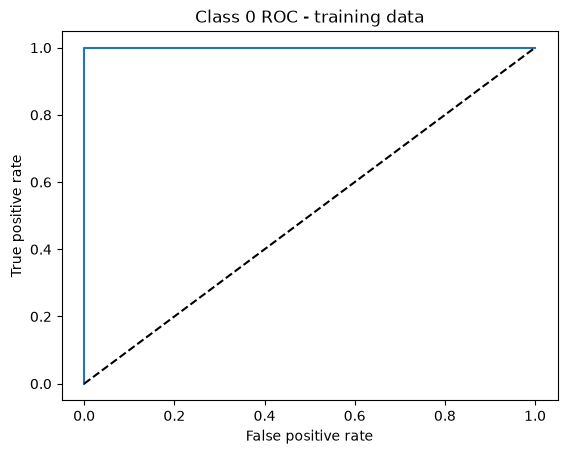

In [3]:
# 2. AUC and ROC for class 0 versus the other classes.
import matplotlib.pyplot as plt

probs = model.predict_proba(dataset.data)
# Iris classes are [0, 1, 2], so column 0 gives the probability of class 0.
class_zero_probs = probs[:, 0]
class_zero_expected = (expected == 0)

auc = metrics.roc_auc_score(class_zero_expected, class_zero_probs)
fpr, tpr, thresholds = metrics.roc_curve(class_zero_expected, class_zero_probs)
print("Class 0 AUC:", auc)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Class 0 ROC - training data")
plt.show()

In [ ]:
# 3. Cross-validation error for the three-class model.
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

scores = cross_val_score(model, dataset.data, dataset.target,
                         cv=5, scoring="accuracy")
print("5-fold CV error:", 1 - scores.mean())

scores = cross_val_score(model, dataset.data, dataset.target,
                         cv=LeaveOneOut(), scoring="accuracy")
print("Leave-one-out CV error:", 1 - scores.mean())

5-fold CV error: 0.026666666666666616


Leave-one-out CV error: 0.033333333333333326
